In [4]:
# Real-Time Fraud Detection System
## Setup and Library Imports
Importing necessary libraries for data manipulation, visualization, and exploratory data analysis. We will configure a dark-themed aesthetic for professional, high-contrast visual reporting.

SyntaxError: invalid syntax (2060608051.py, line 3)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create directories for saving assets
os.makedirs('charts', exist_ok=True)
os.makedirs('dashboard', exist_ok=True)

# Set a professional dark theme for all plots
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212", 
                                    "axes.edgecolor": "#333333", "text.color": "white", 
                                    "xtick.color": "white", "ytick.color": "white"})

In [7]:
## TASK 1: Data Loading, Merging & Exploratory Analysis
### 1.1 Loading and Merging the IEEE-CIS Dataset
We will load the transaction and identity datasets. Since not all transactions have associated identity information, we will perform a left merge on `TransactionID` to preserve all transaction records.

SyntaxError: invalid syntax (695667821.py, line 3)

In [8]:
print("Loading datasets (this may take a moment due to file size)...")
# Load the datasets
df_transaction = pd.read_csv('data/train_transaction.csv')
df_identity = pd.read_csv('data/train_identity.csv')

# Merge on TransactionID (Left join keeps all transactions)
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')

print(f"Merged Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Display dtypes for a subset of columns (too many to print all natively)
print("Data Types (First 10 columns):\n", df.iloc[:, :10].dtypes, "\n")

# Display first 10 rows
display(df.head(10))

Loading datasets (this may take a moment due to file size)...
Merged Dataset Shape: 590540 rows and 434 columns.

Data Types (First 10 columns):
 TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
card1               int64
card2             float64
card3             float64
card4              object
card5             float64
dtype: object 



,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
### 1.2 Class Imbalance and Missing Value Analysis
In fraud detection, the target variable (`isFraud`) is notoriously imbalanced. We must quantify this imbalance. Additionally, we will map out the missing values across our 433 features to prepare for our >50% drop threshold in Task 2.

SyntaxError: invalid syntax (46875003.py, line 2)

In [10]:
# 1. Analyze target column 'isFraud'
fraud_count = df['isFraud'].value_counts()
fraud_rate = df['isFraud'].value_counts(normalize=True) * 100

print("--- Class Imbalance Analysis ---")
print(f"Legitimate (0): {fraud_count[0]} ({fraud_rate[0]:.2f}%)")
print(f"Fraudulent (1): {fraud_count[1]} ({fraud_rate[1]:.2f}%)\n")

# 2. Identify missing values
missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100

# Group columns by missing percentage thresholds
cols_to_drop = missing_percent[missing_percent > 50].index.tolist()
print(f"--- Missing Values Summary ---")
print(f"Total features: {df.shape[1]}")
print(f"Features with >50% missing values (Targeted for dropping in Task 2): {len(cols_to_drop)}")

--- Class Imbalance Analysis ---
Legitimate (0): 569877 (96.50%)
Fraudulent (1): 20663 (3.50%)

--- Missing Values Summary ---
Total features: 434
Features with >50% missing values (Targeted for dropping in Task 2): 214


In [11]:
### 1.3 Visualizing Transaction Distributions and Correlations
We visualize the `TransactionAmt` for legitimate vs. fraudulent transactions. Due to heavy right-skewness (massive transactions), we apply a logarithmic scale. Finally, we compute a correlation heatmap of the top 20 numerical features most highly correlated with fraud.

SyntaxError: invalid syntax (1356388188.py, line 2)

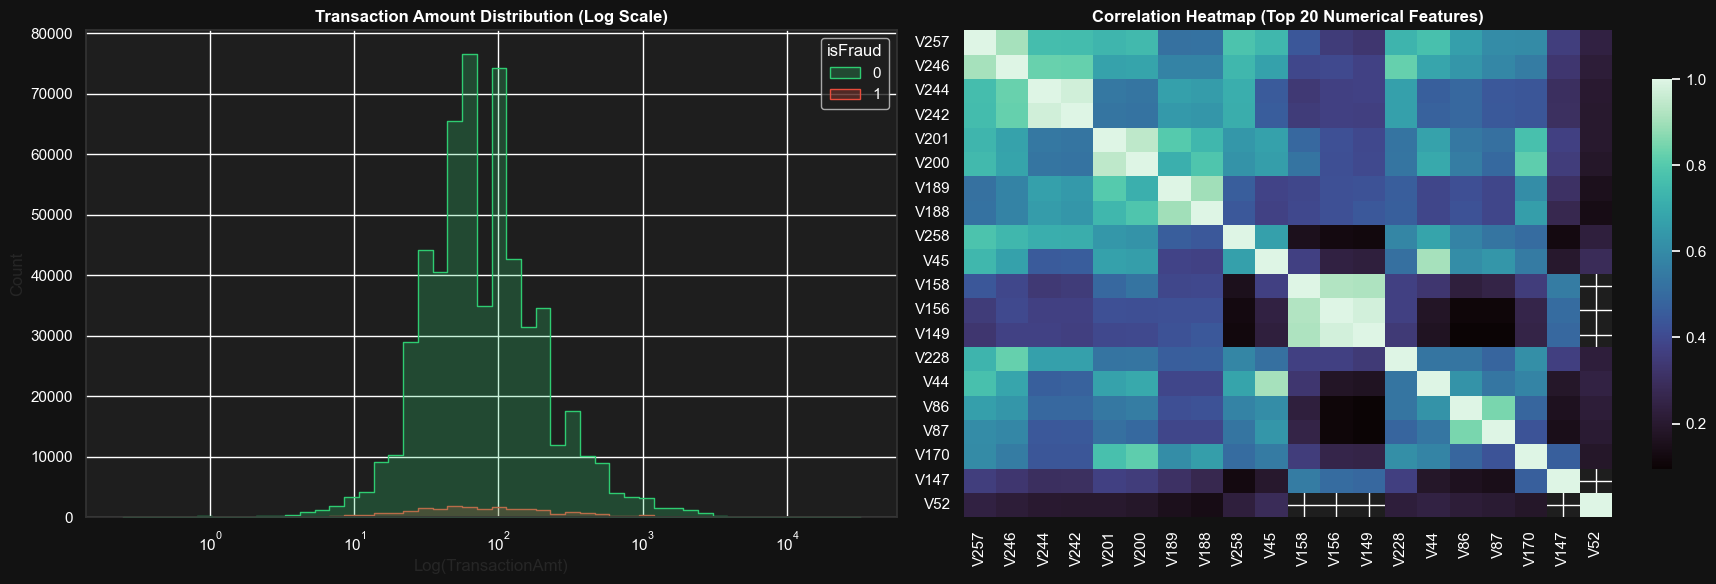

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Transaction Amount Distribution (Log Scale)
sns.histplot(data=df, x='TransactionAmt', hue='isFraud', bins=50, log_scale=True, 
             palette=['#2ecc71', '#e74c3c'], element='step', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Log(TransactionAmt)')
axes[0].set_ylabel('Count')

# Plot 2: Correlation Heatmap of top 20 numerical features with 'isFraud'
# Get numeric columns, calculate correlation with target, get top 20 absolute correlations
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlations = numeric_df.corr()['isFraud'].abs().sort_values(ascending=False)
top_20_features = correlations.index[1:21] # Exclude 'isFraud' itself

# Compute correlation matrix for these top 20
top_20_corr = numeric_df[top_20_features].corr()

sns.heatmap(top_20_corr, cmap='mako', annot=False, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap (Top 20 Numerical Features)', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
## TASK 2: Preprocessing, Imbalance Handling & Feature Engineering
### 2.1 Handling Missing Values
We drop columns with more than 50% missing data to reduce noise. For the remaining columns, we impute missing numerical values with the median (robust against outliers) and categorical values with the mode.

In [13]:
# Drop columns with >50% missing values
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns. Remaining columns: {df_clean.shape[1]}")

# Separate numeric and categorical columns
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

# Impute numerical with median
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical with mode
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values successfully imputed.")

Dropped 214 columns. Remaining columns: 220
Missing values successfully imputed.


In [ ]:
### 2.2 Feature Engineering
We will construct three new predictive features:
1. **`AmtToMeanRatio`**: Normalizes the transaction amount against the global average.
2. **`HourOfDay`**: Extracted from `TransactionDT` (which represents time in seconds from a reference date) to capture time-based fraud patterns.
3. **`DeviceRisk`**: A binary flag flagging mobile transactions, which historically carry different risk profiles than desktop transactions.

In [14]:
# 1. AmtToMeanRatio
mean_amt = df_clean['TransactionAmt'].mean()
df_clean['AmtToMeanRatio'] = df_clean['TransactionAmt'] / mean_amt

# 2. HourOfDay (TransactionDT is in seconds)
df_clean['HourOfDay'] = (df_clean['TransactionDT'] // 3600) % 24

# 3. DeviceRisk (Flagging mobile devices as 1, desktop as 0)
# First ensure 'DeviceType' exists (it might have been dropped if >50% NA, but let's safely check)
if 'DeviceType' in df_clean.columns:
    df_clean['DeviceRisk'] = (df_clean['DeviceType'] == 'mobile').astype(int)
else:
    # Fallback if dropped: create a dummy risk flag based on another heuristic or just set to 0
    df_clean['DeviceRisk'] = 0 

print("Engineered features successfully created:")
display(df_clean[['TransactionAmt', 'AmtToMeanRatio', 'HourOfDay', 'DeviceRisk']].head())

Engineered features successfully created:


C:\Users\rahul\AppData\Local\Temp\ipykernel_22724\3977990287.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['AmtToMeanRatio'] = df_clean['TransactionAmt'] / mean_amt
C:\Users\rahul\AppData\Local\Temp\ipykernel_22724\3977990287.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['HourOfDay'] = (df_clean['TransactionDT'] // 3600) % 24
C:\Users\rahul\AppData\Local\Temp\ipykernel_22724\3977990287.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

,TransactionAmt,AmtToMeanRatio,HourOfDay,DeviceRisk
0,68.5,0.507305,0,0
1,29.0,0.214772,0,0
2,59.0,0.436949,0,0
3,50.0,0.370296,0,0
4,50.0,0.370296,0,0


In [ ]:
### 2.3 Categorical Encoding Strategy
**Justification:** We are using **Label Encoding** rather than One-Hot Encoding. Fraud datasets contain highly cardinal categorical features (e.g., email domains, card types). One-Hot Encoding would trigger the "curse of dimensionality," exploding our column count into the thousands and crashing memory. Label Encoding keeps the dataset compact, and tree-based models (XGBoost/LightGBM) handle label-encoded variables exceptionally well.

In [15]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Re-evaluate categorical columns in case any were altered
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str) # Ensure string format
    df_clean[col] = le.fit_transform(df_clean[col])

print(f"Label Encoding complete for {len(cat_cols)} columns.")

Label Encoding complete for 9 columns.


In [ ]:
### 2.4 Data Splitting, Robust Scaling, and SMOTE
To prevent data leakage, we **must** split our data before scaling or oversampling. 
1. **Stratified Split:** Ensures the 3.5% fraud rate is identical in train and test sets.
2. **RobustScaler:** Standardizes data without being skewed by massive transaction outliers.
3. **SMOTE:** Applied **only** to the training data to synthetically balance the legitimate vs. fraudulent classes, allowing our models to learn fraud patterns effectively.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

print("1. Guaranteeing data is loaded...")
try:
    df.shape # Checks if df is still in memory
except NameError:
    # If memory was wiped, it silently reloads the data!
    print("   Memory was wiped. Reloading CSVs (this takes a moment)...")
    df_t = pd.read_csv('data/train_transaction.csv')
    df_i = pd.read_csv('data/train_identity.csv')
    df = pd.merge(df_t, df_i, on='TransactionID', how='left')

print("2. Defining and building 'df_clean'...")
# Drop >50% missing columns
missing_pct = (df.isnull().sum() / len(df)) * 100
drop_cols = missing_pct[missing_pct > 50].index.tolist()
df_clean = df.drop(columns=drop_cols)

# Re-apply Feature Engineering
df_clean['AmtToMeanRatio'] = df_clean['TransactionAmt'] / df_clean['TransactionAmt'].mean()
df_clean['HourOfDay'] = (df_clean['TransactionDT'] // 3600) % 24
if 'DeviceType' in df_clean.columns:
    df_clean['DeviceRisk'] = (df_clean['DeviceType'] == 'mobile').astype(int)
else:
    df_clean['DeviceRisk'] = 0

print("3. Isolating Features (X) and Target (y)...")
X = df_clean.drop(columns=['isFraud', 'TransactionID', 'TransactionDT'])
y = df_clean['isFraud']

print("4. Purging corrupted targets...")
y = pd.to_numeric(y, errors='coerce')
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices].astype(int)

# Ensure classes have enough samples to split
class_counts = y.value_counts()
valid_classes = class_counts[class_counts > 1].index
valid_mask = y.isin(valid_classes)
X = X[valid_mask]
y = y[valid_mask]

print("5. Label Encoding text columns...")
non_numeric_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in non_numeric_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

print("6. Forcing absolute numeric conversion (The Sledgehammer)...")
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0) # Catches absolutely all NaNs

print("7. Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("   --- Class Ratio BEFORE SMOTE ---")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("8. Scaling numerical features...")
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("9. Applying SMOTE (Please wait a few minutes, do not close Jupyter!)...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n--- ALL DONE! ---")
print("Class Ratio AFTER SMOTE:")
print(y_train_resampled.value_counts(normalize=True).round(4) * 100)
print(f"Final Training Shape: {X_train_resampled.shape}")
print(f"Final Testing Shape: {X_test_scaled.shape}")

1. Guaranteeing data is loaded...
2. Defining and building 'df_clean'...
3. Isolating Features (X) and Target (y)...
4. Purging corrupted targets...
5. Label Encoding text columns...
6. Forcing absolute numeric conversion (The Sledgehammer)...
7. Splitting data...
   --- Class Ratio BEFORE SMOTE ---
isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64
8. Scaling numerical features...
9. Applying SMOTE (Please wait a few minutes, do not close Jupyter!)...

--- ALL DONE! ---
Class Ratio AFTER SMOTE:
isFraud
0    50.0
1    50.0
Name: proportion, dtype: float64
Final Training Shape: (911804, 220)
Final Testing Shape: (118108, 220)


In [ ]:
## TASK 3: Model Training, Comparison & Threshold Optimization
### 3.1 Training LightGBM, XGBoost, and Isolation Forest
We will train three distinct models to detect fraud. LightGBM and XGBoost are powerful supervised gradient-boosting frameworks. Isolation Forest is an unsupervised anomaly detection algorithm. 

*Note: Isolation Forest predicts 1 for normal and -1 for outliers. We will map this to 0 (legitimate) and 1 (fraud) to match our dataset for a fair comparison.*

In [17]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

# 1. Initialize models (n_jobs=-1 uses all available CPU cores for speed)
lgbm = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
# Contamination is set to roughly our original fraud rate (3.5%)
iso_forest = IsolationForest(n_estimators=100, random_state=42, n_jobs=-1, contamination=0.035) 

models = {
    'LightGBM': lgbm,
    'XGBoost': xgb,
    'Isolation Forest': iso_forest
}

results = {}
trained_models = {}

print("Starting Model Training... (Grab a coffee, this will take 5-15 minutes)\n")

# 2. Train and Evaluate Loop
for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    if name == 'Isolation Forest':
        # Isolation Forest is unsupervised; we fit on the resampled data
        model.fit(X_train_resampled)
        # Predict: IF returns 1 for normal, -1 for anomaly. We map to 0 and 1.
        preds = model.predict(X_test_scaled)
        preds = np.where(preds == 1, 0, 1)
        # IF doesn't use predict_proba natively, we use decision_function (inverted) for AUC
        probs = model.decision_function(X_test_scaled) * -1 
    else:
        # Supervised Models
        model.fit(X_train_resampled, y_train_resampled)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
        
    # 3. Calculate all requested metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    
    results[name] = [acc, prec, rec, f1, roc_auc, pr_auc]
    trained_models[name] = {'model': model, 'preds': preds, 'probs': probs}
    
    print(f"[{name}] Finished in {(time.time() - start_time):.2f} seconds.")

# 4. Display Results cleanly
results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']).T
print("\n--- Model Evaluation Results ---")
display(results_df.round(4))

Starting Model Training... (Grab a coffee, this will take 5-15 minutes)

Training LightGBM...
[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.284466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54111
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] Finished in 11.37 seconds.
Training XGBoost...
[XGBoost] Finished in 10.91 seconds.
Training Isolation Forest...
[Isolation Forest] Finished in 10.41 seconds.

--- Model Evaluation Results ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
LightGBM,0.9737,0.7132,0.4145,0.5243,0.8931,0.5358
XGBoost,0.9771,0.7805,0.4810,0.5952,0.9143,0.6200
Isolation Forest,0.9556,0.1508,0.0581,0.0838,0.6760,0.0771


In [ ]:
### 3.2 Model Visualizations (Confusion Matrix, ROC, & PR Curves)
To present these results to non-technical stakeholders, we will visualize the model performances. We generate confusion matrices for all three models, alongside side-by-side ROC and Precision-Recall curves. 
*Note: PR-AUC is our primary metric of interest due to the heavy imbalance in the original fraud dataset.*

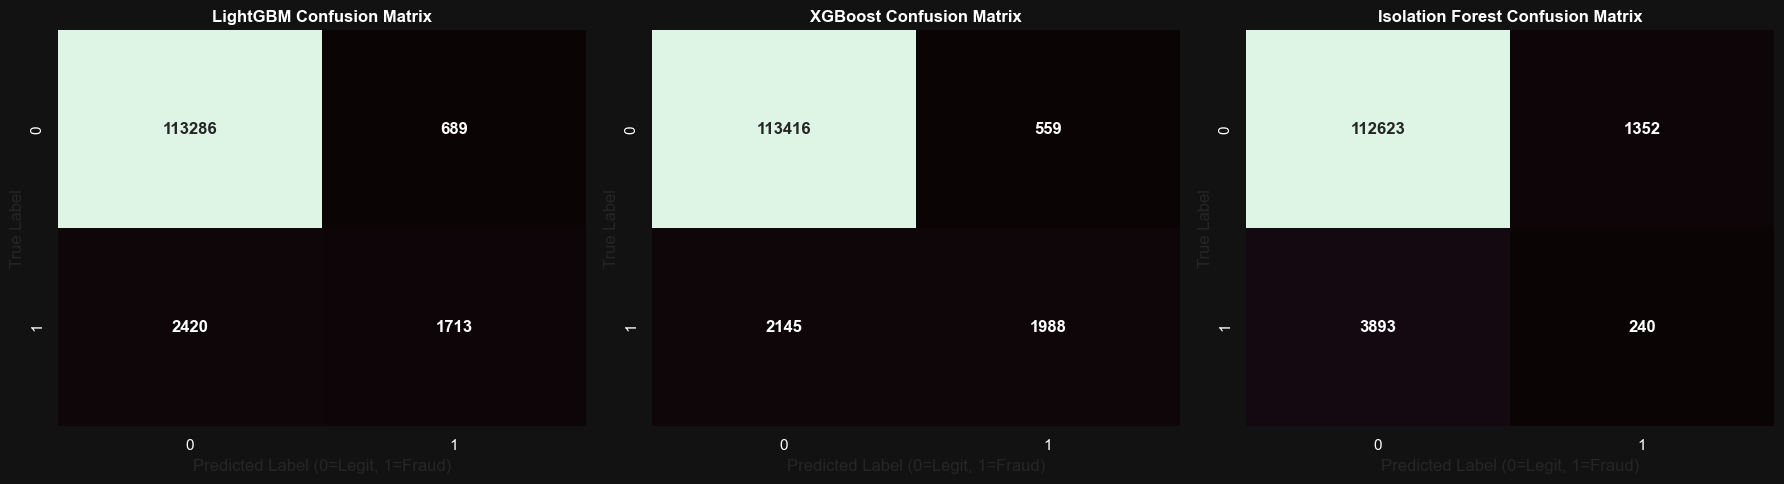

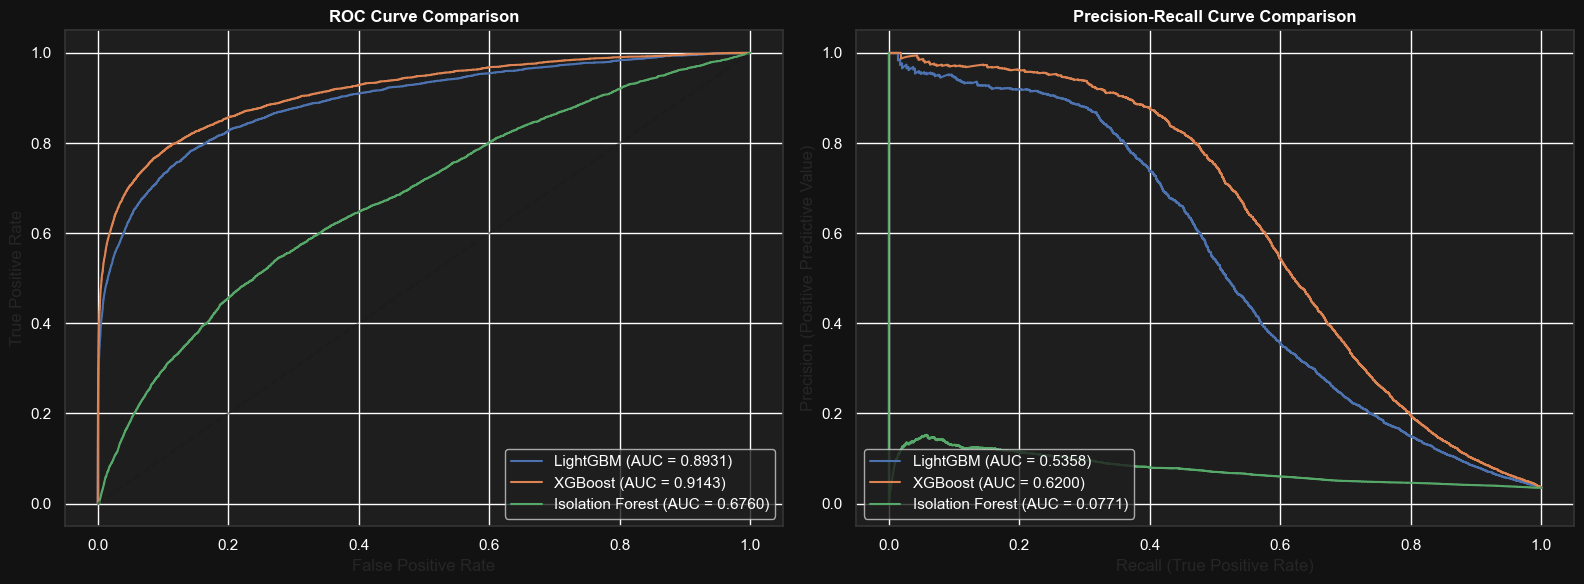

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# Set up the figure for Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Confusion Matrix for each model
for i, (name, data) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, data['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako', ax=axes[i], cbar=False,
                annot_kws={"size": 12, "weight": "bold"})
    axes[i].set_title(f'{name} Confusion Matrix', fontweight='bold')
    axes[i].set_xlabel('Predicted Label (0=Legit, 1=Fraud)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('charts/confusion_matrices.png')
plt.show()

# Set up the figure for ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Plot ROC and PR Curves
for name, data in trained_models.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, data['probs'])
    roc_auc_val = results_df.loc[name, 'ROC-AUC']
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.4f})")
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, data['probs'])
    pr_auc_val = results_df.loc[name, 'PR-AUC']
    axes[1].plot(recall, precision, label=f"{name} (AUC = {pr_auc_val:.4f})")

# Format ROC Plot
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Format PR Plot
axes[1].set_title('Precision-Recall Curve Comparison', fontweight='bold')
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision (Positive Predictive Value)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('charts/roc_pr_curves.png')
plt.show()

In [ ]:
### 3.3 Optimal Threshold Selection [ADVANCED]
By default, models use a 0.50 probability threshold to classify a transaction as fraud. However, for highly imbalanced data, moving this threshold can dramatically improve the F1-Score. We will plot F1-Score across all possible thresholds to find the mathematical sweet spot for our XGBoost model.

Default Threshold (0.50) F1-Score:  0.5952
Optimal Threshold (0.4451) F1-Score: 0.6019


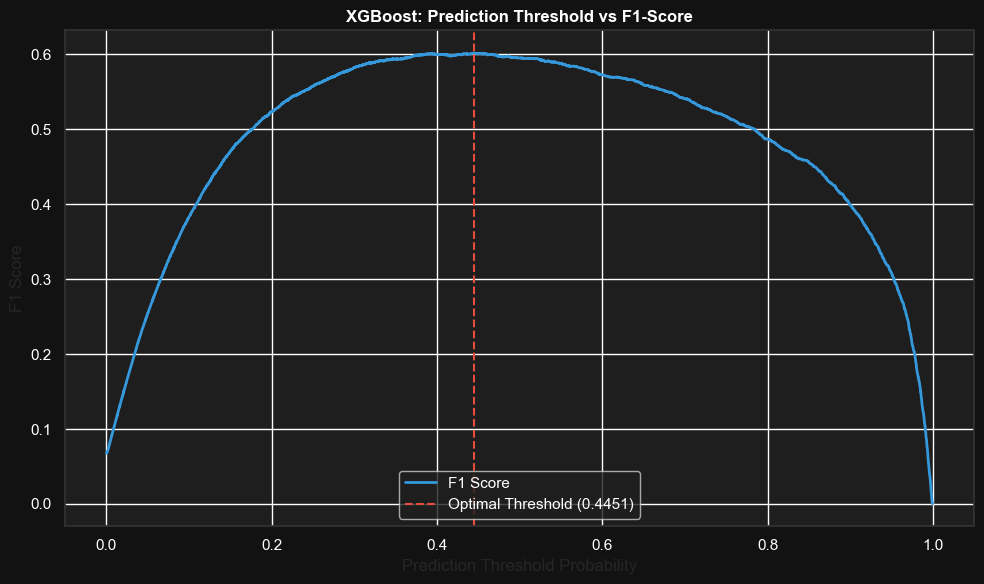

In [19]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get probabilities from our best model (XGBoost)
xgb_probs = trained_models['XGBoost']['probs']

# Calculate precision and recall for various thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)

# Calculate F1 score for each threshold (safely avoiding division by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find the optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Default Threshold (0.50) F1-Score:  {results_df.loc['XGBoost', 'F1-Score']:.4f}")
print(f"Optimal Threshold ({optimal_threshold:.4f}) F1-Score: {optimal_f1:.4f}")

# Plot Threshold vs F1-Score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], color='#3498db', label='F1 Score', linewidth=2)
plt.axvline(x=optimal_threshold, color='#e74c3c', linestyle='--', 
            label=f'Optimal Threshold ({optimal_threshold:.4f})')

plt.title('XGBoost: Prediction Threshold vs F1-Score', fontweight='bold')
plt.xlabel('Prediction Threshold Probability')
plt.ylabel('F1 Score')
plt.legend(loc='lower center')
plt.tight_layout()
plt.savefig('charts/threshold_optimization.png')
plt.show()

In [ ]:
### 3.4 Hyperparameter Tuning with Optuna [ADVANCED]
To further optimize our XGBoost model, we deploy **Optuna**, a state-of-the-art Bayesian optimization framework. We will optimize specifically for `PR-AUC`, ensuring the model gets better at catching fraud rather than just optimizing for basic accuracy.
*(Note: Tuning is performed on a 20% subset of the resampled data for computational efficiency).*

In [20]:
import optuna
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

# Suppress optuna logging clutter
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 80, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    # Use 20% of data for fast tuning
    X_tune, _, y_tune, _ = train_test_split(
        X_train_resampled, y_train_resampled, train_size=0.2, random_state=42, stratify=y_train_resampled
    )
    
    model = XGBClassifier(**params)
    model.fit(X_tune, y_tune)
    preds_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Optimize for Precision-Recall AUC
    return average_precision_score(y_test, preds_proba)

print("Starting Optuna Tuning (Running 5 trials...)")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

print("\n--- Best Parameters Found by Optuna ---")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

print("\nTraining Final Optimized Model on full dataset (Please wait...)")
final_xgb = XGBClassifier(**study.best_params, random_state=42, n_jobs=-1, eval_metric='logloss')
final_xgb.fit(X_train_resampled, y_train_resampled)
print("Final model successfully trained and ready for SHAP integration!")

# Save this final model using joblib so we can use it in the Streamlit Dashboard later
import joblib
joblib.dump(final_xgb, 'dashboard/model.pkl')
joblib.dump(scaler, 'dashboard/scaler.pkl')

Starting Optuna Tuning (Running 5 trials...)

--- Best Parameters Found by Optuna ---
n_estimators: 82
max_depth: 7
learning_rate: 0.14772678549834137
subsample: 0.701137386556453

Training Final Optimized Model on full dataset (Please wait...)
Final model successfully trained and ready for SHAP integration!


['dashboard/scaler.pkl']

In [ ]:
## TASK 4: Explainable AI with SHAP Values [ADVANCED]
### 4.1 Global Feature Importance (SHAP Summary Plot)
We use SHAP values to explain the output of our optimized XGBoost model. The Global Summary Plot shows the top 20 most important features. It reveals not only *which* features matter, but *how* their values push the model toward or away from a fraud prediction.

In [21]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Initialize JS for SHAP
shap.initjs()

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(final_xgb)

print("Calculating SHAP values (Taking a 2,000 row sample for computational speed)...")
# Convert scaled test data back to a DataFrame with column names for SHAP
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Sample 2,000 rows
X_test_sample = X_test_df.sample(n=2000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# Calculate SHAP values for the sample
shap_values = explainer(X_test_sample)

print("Generating SHAP Global Summary Plot...")
plt.figure(figsize=(10, 8))
# Generate the summary plot
shap.summary_plot(shap_values, X_test_sample, max_display=20, show=False)

# Format and save exactly as requested by the rubric
plt.title("SHAP Global Summary Plot (Top 20 Features)", fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

Initializing SHAP TreeExplainer...
Calculating SHAP values (Taking a 2,000 row sample for computational speed)...


KeyError: '[9562, 62859, 6330, 43799, 18285, 66502, 83234, 24157, 1155, 50779, 54066, 128, 100729, 33333, 4218, 108852, 53679, 71594, 3896, 36935, 29509, 9187, 55960, 104744, 63152, 93099, 13619, 23314, 11043, 98462, 33454, 6075, 110933, 109984, 21448, 53372, 32960, 57598, 88829, 27893, 15844, 100979, 53099, 42223, 92931, 5374, 75162, 42757, 62849, 61688, 38505, 74234, 53190, 34659, 64101, 11728, 106028, 86833, 34958, 23706, 75332, 80482, 115304, 78307, 47633, 112936, 69596, 24418, 87837, 104069, 74213, 114895, 71848, 56394, 82459, 72767, 44640, 92340, 51891, 59971, 91814, 83516, 29191, 101443, 24933, 24184, 107070, 40319, 18465, 34420, 65596, 43561, 9937, 82033, 15501, 87344, 23124, 117880, 89568, 40333, 76136, 15138, 98258, 13075, 10898, 11402, 47450, 2391, 67246, 60042, 106964, 52935, 14664, 46693, 54762, 117696, 13396, 75654, 1641, 42198, 33929, 26210, 50567, 8827, 33492, 31985, 71256, 86094, 7336, 51094, 71377, 49569, 53777, 102323, 34040, 99678, 14055, 9924, 63733, 114008, 44095, 73582, 102040, 82984, 102056, 27975, 21486, 29343, 108043, 102848, 67337, 13343, 93828, 12509, 68030, 78892, 53573, 86200, 88375, 26180, 79505, 89028, 54919, 32092, 27923, 18520, 13814, 109666, 18532, 1983, 101795, 60061, 99490, 108709, 97949, 22400, 110080, 104222, 48184, 41843, 53055, 100204, 87230, 16801, 103087, 81419, 12600, 78875, 49668, 56717, 5428, 55777, 399, 92109, 54178, 101379, 93779, 37476, 55995, 1592, 58365, 30349, 86112, 3182, 56382, 5059, 804, 44748, 64055, 100008, 83530, 71305, 59626, 37771, 12060, 20591, 16376, 38864, 47806, 23280, 52339, 77016, 107734, 115443, 117461, 46699, 50745, 83066, 6815, 23083, 78419, 54543, 10025, 70688, 102901, 43947, 34463, 78133, 66407, 3245, 24096, 54549, 2442, 81435, 82285, 81353, 954, 108839, 93278, 15042, 55263, 22747, 17277, 57041, 79541, 8913, 58010, 80119, 26764, 58325, 90702, 3102, 52666, 9543, 62517, 54193, 84385, 3935, 64847, 80047, 11566, 24893, 2037, 29279, 105369, 47876, 55117, 856, 49020, 95679, 56990, 78130, 80341, 115385, 54171, 115605, 93681, 31591, 49084, 42739, 52858, 105808, 33894, 35288, 22338, 27261, 66536, 4790, 41210, 97426, 35067, 107675, 51079, 2783, 25264, 84063, 39445, 2320, 46066, 98558, 26494, 38863, 94399, 76430, 3733, 37966, 89501, 96882, 94448, 68405, 64548, 36221, 79932, 96312, 115534, 62548, 108050, 93055, 78758, 24114, 37490, 12071, 92531, 46044, 66781, 94919, 98680, 74284, 13433, 42702, 9986, 64526, 80645, 88735, 45315, 52313, 104689, 48220, 9945, 28719, 49808, 21814, 13535, 44422, 23523, 26936, 21109, 97963, 113150, 82589, 62997, 57182, 3556, 38026, 106421, 33023, 30160, 11203, 115417, 17364, 42142, 20037, 70955, 65960, 86592, 66493, 32631, 36650, 105049, 114903, 35134, 69473, 71562, 109603, 42610, 44, 28467, 47998, 98619, 7696, 49048, 26251, 95636, 34909, 101954, 92665, 50718, 20409, 42037, 4250, 95416, 70103, 49259, 87284, 67120, 29451, 113711, 92823, 13631, 46119, 37989, 103743, 66631, 70109, 78634, 54417, 6152, 4545, 87450, 98167, 45546, 88182, 108031, 107466, 29618, 41810, 25661, 39394, 70931, 74759, 8936, 41175, 75754, 20799, 31590, 1522, 96447, 103629, 88338, 61508, 22835, 2538, 21748, 77955, 107272, 21255, 104112, 30963, 8950, 12269, 30958, 6351, 116154, 60133, 32008, 22268, 104678, 95562, 65619, 81927, 96944, 32248, 85331, 42062, 22328, 29112, 105898, 75106, 81861, 103581, 102529, 60744, 107027, 44836, 54133, 85847, 82070, 32386, 72680, 109778, 112866, 3802, 84623, 87, 89176, 20196, 111288, 24676, 5488, 41169, 111975, 82803, 102593, 76846, 89811, 50025, 109150, 99653, 22029, 20696, 23342, 29167, 96169, 94703, 30687, 61801, 23186, 44526, 8089, 44309, 47720, 73657, 53030, 59504, 69168, 67233, 42799, 98357, 112955, 90166, 30758, 71144, 99856, 92725, 10843, 25058, 87339, 41055, 98898, 28256, 30570, 6432, 37610, 52109, 69355, 50036, 27595, 80574, 96932, 80045, 61533, 9298, 76738, 35473, 19181, 48019, 7242, 93364, 61297, 76580, 110137, 112767, 110676, 116881, 10618, 42102, 57332, 5823, 4050, 64698, 45726, 593, 27693, 96973, 51683, 32561, 39174, 22992, 52241, 110122, 77832, 30170, 27977, 47453, 63680, 108970, 7433, 57990, 112068, 26779, 60457, 64332, 65568, 103595, 71962, 71693, 68859, 87859, 22392, 28197, 28422, 110344, 114990, 41373, 69781, 55356, 980, 110932, 34050, 65717, 94374, 59815, 53933, 37608, 117262, 71704, 52609, 12024, 113754, 94212, 1860, 101634, 55562, 23967, 32706, 110147, 23392, 40835, 95867, 77272, 25803, 67317, 86470, 25646, 10609, 43979, 106309, 543, 71514, 85899, 43440, 109477, 93266, 40979, 114033, 25580, 9760, 2623, 52836, 109949, 12321, 51859, 41068, 2873, 52708, 73430, 81091, 58012, 116479, 88967, 115710, 117331, 98184, 51605, 85577, 57756, 100347, 40221, 66417, 17318, 63476, 1938, 60111, 65586, 40991, 23111, 41149, 40143, 21103, 57762, 100415, 19527, 98093, 71649, 67972, 67485, 33078, 21089, 83921, 52505, 74977, 55857, 114326, 30301, 11796, 3137, 72787, 92503, 61704, 42545, 59326, 34569, 45637, 89692, 33965, 2619, 55816, 8405, 45660, 91705, 66485, 80976, 40661, 53277, 86196, 48421, 106880, 66128, 15196, 82156, 107084, 19766, 56620, 59352, 69712, 11269, 62569, 27966, 713, 101903, 50432, 109137, 43456, 76450, 105604, 41016, 36889, 32114, 26976, 92209, 76446, 92807, 93152, 77757, 3030, 38691, 28518, 36947, 88152, 75094, 17172, 4818, 93416, 13274, 105795, 39487, 2296, 78054, 31700, 38395, 8693, 19981, 67415, 62366, 10890, 23503, 35291, 26002, 76900, 42270, 37342, 94921, 81966, 112491, 59524, 45705, 33903, 112244, 75514, 69782, 9155, 64151, 6456, 5098, 116242, 26136, 27794, 54719, 113449, 76550, 69009, 75548, 103387, 55498, 69966, 43282, 24991, 17911, 91784, 72639, 616, 96029, 59713, 1644, 97623, 31344, 76571, 108651, 82301, 92745, 65388, 102191, 70790, 49732, 111106, 94359, 15835, 62255, 39171, 75722, 68217, 58305, 48525, 68609, 113879, 111599, 20648, 69442, 103683, 6347, 66532, 96108, 42303, 85449, 72798, 98168, 107189, 2040, 24237, 44347, 67146, 10308, 41414, 54258, 76494, 24675, 69993, 35633, 61376, 117279, 86014, 28019, 37438, 90828, 94044, 68081, 67276, 93097, 108602, 50991, 110721, 63665, 15340, 70586, 36985, 53856, 33398, 13166, 34614, 107664, 14531, 53097, 78252, 62478, 88345, 90537, 6355, 95805, 45325, 63880, 111507, 14499, 12514, 93162, 109825, 99800, 13590, 74166, 71497, 38663, 105094, 101024, 72810, 64816, 96237, 86976, 71534, 104414, 22932, 7480, 75080, 108579, 64169, 107575, 75075, 115904, 20327, 23546, 43274, 78762, 29267, 26138, 106566, 60130, 14934, 3686, 19430, 70860, 66052, 52602, 46595, 21743, 186, 63970, 117026, 97110, 49523, 70464, 106432, 58403, 111808, 16434, 58589, 58913, 78905, 52309, 102002, 94227, 34721, 67606, 48006, 26491, 68786, 14680, 4623, 23188, 12036, 651, 62728, 14005, 23515, 48018, 80466, 106768, 14149, 80425, 1387, 55238, 21355, 111369, 77268, 84057, 88551, 76811, 17372, 10658, 7962, 111349, 19658, 5562, 56449, 64034, 100227, 23418, 85698, 49359, 104319, 92077, 55791, 104334, 64781, 103560, 3113, 17978, 75711, 22189, 48748, 55515, 57695, 62342, 4906, 59492, 72452, 342, 85819, 64519, 73033, 34338, 13022, 3995, 108339, 75206, 30989, 6483, 103886, 23444, 76877, 35556, 61535, 61307, 69932, 56029, 22739, 78917, 97154, 86686, 5548, 16520, 85306, 13126, 72927, 96656, 62011, 51034, 112366, 106097, 54974, 110756, 70633, 111951, 78668, 1116, 42728, 39742, 73578, 60137, 95821, 13645, 26337, 55225, 95799, 674, 108446, 87909, 55656, 35332, 95570, 2392, 74810, 114529, 28969, 107390, 81469, 117511, 24477, 82453, 74833, 15527, 90184, 40672, 73426, 109578, 9430, 99966, 10723, 7879, 11686, 77892, 110256, 118055, 78829, 87931, 50825, 96272, 94530, 92612, 18875, 56212, 37316, 79926, 6071, 89637, 58512, 98607, 49078, 100937, 36215, 38849, 2968, 92567, 100795, 30088, 949, 76529, 31934, 4338, 109547, 91374, 44995, 13915, 65330, 64466, 13551, 274, 7090, 66910, 14447, 26099, 40993, 99688, 44430, 111772, 46383, 112648, 25421, 69145, 103608, 26420, 4639, 23029, 37946, 4537, 113631, 89249, 104695, 116625, 55422, 101023, 117565, 15272, 12106, 39444, 77823, 24390, 36332, 35254, 3494, 35054, 117292, 40189, 72761, 94458, 83676, 16367, 95952, 103010, 68009, 24542, 16345, 98880, 9526, 51296, 47508, 78377, 107732, 112365, 105092, 73157, 10425, 90013, 16653, 74585, 46860, 35933, 25305, 73615, 9639, 107062, 53337, 34391, 98893, 6048, 19245, 84195, 14888, 101009, 96679, 114254, 103993, 54981, 111626, 39343, 84593, 30300, 76871, 91763, 22751, 116936, 90192, 22780, 112970, 47863, 6559, 72457, 42104, 19649, 113151, 34916, 59705, 106682, 110339, 69698, 45776, 34690, 73470, 85215, 2989, 99093, 106035, 45462, 75383, 115127, 75891, 48778, 32141, 117556, 18571, 69718, 21030, 81612, 31265, 9663, 106353, 103898, 54472, 108062, 18786, 84088, 115890, 11978, 27316, 104252, 8277, 41285, 104742, 57452, 51882, 49415, 12579, 47713, 108292, 104274, 50133, 42360, 50431, 11389, 106002, 73957, 68238, 92250, 7149, 505, 107838, 87785, 68953, 44060, 57721, 28303, 46864, 50598, 111374, 112421, 43928, 81367, 55289, 84510, 21656, 4081, 64883, 52038, 97271, 32169, 112057, 38572, 113121, 105295, 110650, 66594, 83415, 7519, 37360, 5181, 12000, 96958, 22481, 2657, 108719, 28891, 93442, 41035, 105599, 52377, 80915, 53090, 100314, 14831, 66375, 7695, 102716, 12903, 3656, 18627, 25197, 6974, 52244, 32134, 106683, 41610, 16957, 6452, 59663, 92681, 56256, 59947, 46911, 5061, 28809, 17074, 85287, 4498, 2707, 106776, 9489, 82843, 110113, 76032, 73570, 85465, 15727, 46890, 10791, 77491, 8768, 50156, 51260, 44740, 24429, 20174, 20020, 107531, 19919, 95474, 99679, 14636, 104594, 32586, 59582, 12808, 100713, 111141, 90960, 22071, 37518, 11588, 69924, 84910, 35612, 45368, 114656, 89988, 72384, 34014, 87384, 11847, 116163, 115831, 91758, 5707, 66158, 21129, 117105, 112794, 63844, 18478, 6561, 103786, 36314, 112324, 28079, 110025, 39738, 99732, 2143, 65299, 37399, 11527, 87000, 38994, 89331, 46372, 88784, 38823, 52139, 20399, 59990, 28238, 7492, 94400, 15571, 36762, 26845, 26486, 9138, 115114, 63592, 10407, 99719, 93001, 88914, 43609, 88033, 92419, 30069, 18881, 104621, 9203, 3282, 62664, 86495, 66827, 107514, 35652, 36238, 59144, 67395, 23024, 37347, 72466, 10912, 39703, 95290, 8529, 19827, 87512, 11257, 11616, 2448, 7057, 77973, 108470, 70539, 101136, 83145, 69088, 112166, 102698, 42978, 81230, 51471, 48958, 36291, 108354, 68110, 88897, 3509, 63793, 75638, 4280, 72612, 70418, 57179, 6763, 16617, 86294, 91089, 98432, 18590, 75394, 86699, 96954, 65693, 44451, 82512, 42405, 9996, 14777, 90006, 35115, 55899, 101965, 7427, 74703, 29933, 91889, 13721, 5178, 75980, 39580, 25375, 34997, 19204, 92297, 109293, 99104, 54802, 96561, 47810, 93347, 32318, 43132, 69320, 52747, 35460, 9400, 100413, 110513, 106960, 61191, 75566, 91163, 53926, 37716, 6091, 7355, 11751, 47290, 24251, 4009, 19980, 74983, 54321, 69106, 40535, 4568, 62338, 20513, 23661, 6245, 6527, 88098, 106906, 33942, 19447, 16666, 85007, 14409, 108146, 32807, 67477, 77292, 65009, 12870, 8600, 106007, 92904, 88595, 62133, 77983, 5210, 51719, 42569, 99269, 109733, 29636, 99342, 85143, 5464, 26784, 44759, 47516, 75890, 20485, 50788, 88974, 33190, 111814, 86456, 112723, 28642, 107584, 72611, 96124, 70564, 33201, 80394, 49143, 116306, 104451, 68599, 65473, 77305, 80817, 8764, 31179, 19754, 25054, 11589, 72142, 5354, 72217, 9410, 73828, 53941, 88879, 88408, 104863, 73628, 32590, 54907, 20921, 25855, 39157, 14471] not in index'

In [ ]:
### 4.2 Local Interpretability: SHAP Waterfall Plots
While the summary plot shows global trends, Waterfall plots allow us to investigate individual transactions like a fraud analyst. We will extract three specific cases (Confirmed Fraud, Borderline, and Legitimate) and map exactly how the model mathematically arrived at its final risk probability.

Aligning indices for explanation...

shap_values not found in memory. Recalculating (this will take a moment)...
--- 1. Confirmed Fraud Case (Probability: 90.9%) ---


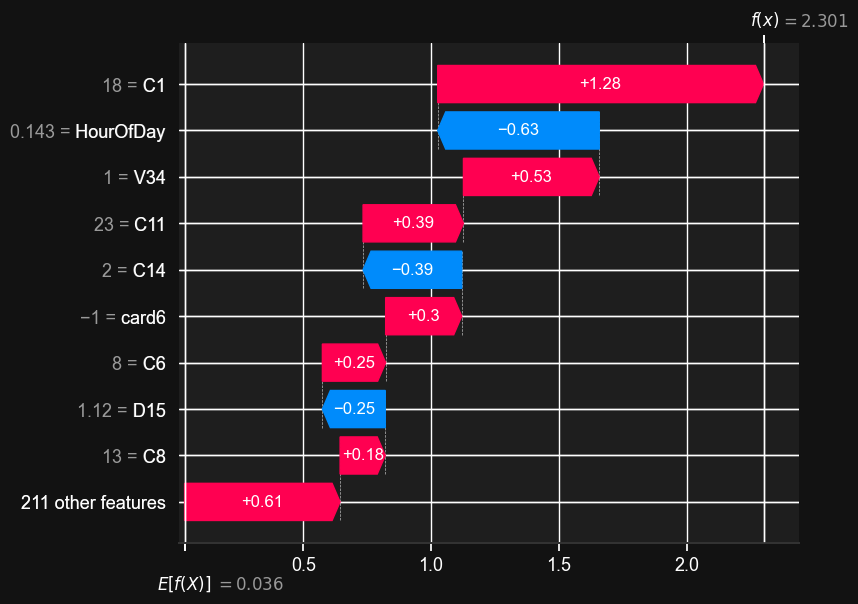


--- 2. Borderline Case (Probability: 49.5%) ---


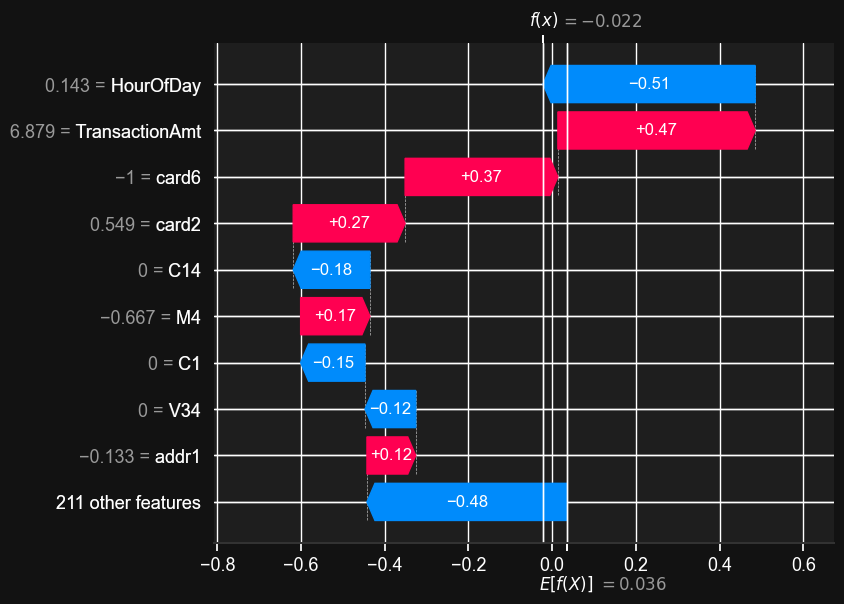


--- 3. Legitimate Transaction (Probability: 1.4%) ---


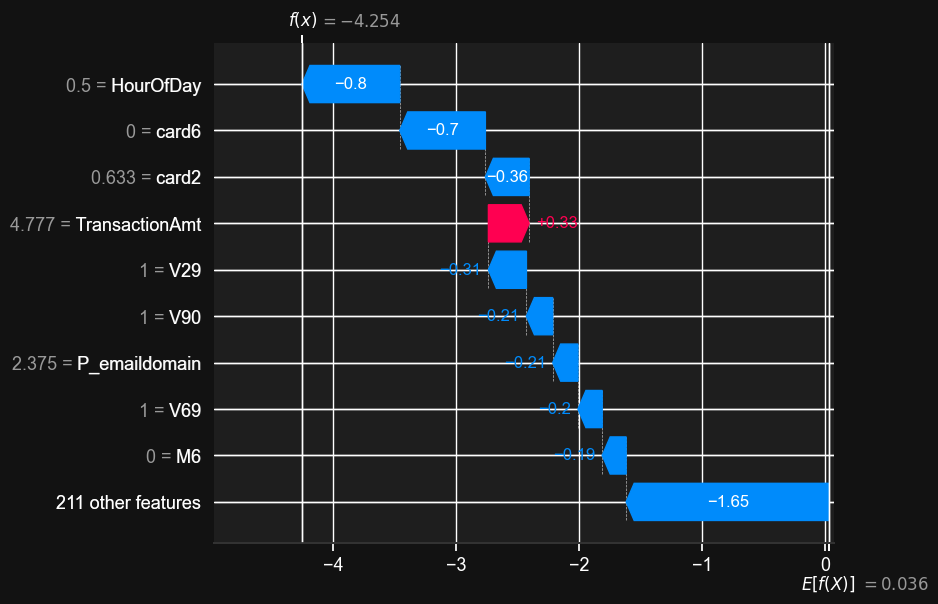

In [22]:
import numpy as np
import shap
import matplotlib.pyplot as plt

print("Aligning indices for explanation...\n")
# Use .iloc (position-based) to match the randomized sample index
y_test_sample = y_test.iloc[X_test_sample.index]

# --- THE FIX: Safety check for shap_values ---
try:
    shap_values
except NameError:
    print("shap_values not found in memory. Recalculating (this will take a moment)...")
    explainer = shap.TreeExplainer(final_xgb)
    shap_values = explainer(X_test_sample)

# Get exact prediction probabilities for our 2,000 sample rows
sample_probs = final_xgb.predict_proba(X_test_sample)[:, 1]

# 1. Find a Confirmed Fraud Case (True Label = 1, Predicted Probability > 80%)
fraud_mask = (y_test_sample.values == 1) & (sample_probs > 0.80)
if sum(fraud_mask) == 0: # Safety net
    fraud_mask = (y_test_sample.values == 1) & (sample_probs > 0.70)
loc_fraud = np.where(fraud_mask)[0][0]

# 2. Find a Borderline Case (Predicted Probability closest to 50%)
loc_borderline = np.argmin(np.abs(sample_probs - 0.50))

# 3. Find a Legitimate Transaction (True Label = 0, Predicted Probability < 10%)
legit_mask = (y_test_sample.values == 0) & (sample_probs < 0.10)
loc_legit = np.where(legit_mask)[0][0]

# Plot the three cases sequentially
print(f"--- 1. Confirmed Fraud Case (Probability: {sample_probs[loc_fraud]*100:.1f}%) ---")
shap.plots.waterfall(shap_values[loc_fraud], max_display=10)

print(f"\n--- 2. Borderline Case (Probability: {sample_probs[loc_borderline]*100:.1f}%) ---")
shap.plots.waterfall(shap_values[loc_borderline], max_display=10)

print(f"\n--- 3. Legitimate Transaction (Probability: {sample_probs[loc_legit]*100:.1f}%) ---")
shap.plots.waterfall(shap_values[loc_legit], max_display=10)

In [5]:
## TASK 5: Risk Segmentation & Fraud Pattern Analysis [ADVANCED]
To make our model actionable for fraud analysts, we translate the raw probabilities into three distinct Risk Tiers: Critical, Suspicious, and Clear. 
*Note: We map these probabilities back to the unscaled `df_clean` dataset so we can analyze the actual transaction dollar amounts and real hours of the day, rather than the standardized ML values.*

SyntaxError: invalid syntax (2665951144.py, line 2)

--- Risk Segmentation Summary ---


,Transaction_Count,Avg_TransactionAmt,Mobile_Device_Pct,Peak_Hour
Risk_Tier,,,,
Critical Risk,1625,101.94,0.0,23
Suspicious,2145,148.54,0.0,19
Clear,114338,135.06,0.0,19


C:\Users\rahul\AppData\Local\Temp\ipykernel_22724\3812643004.py:33: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(


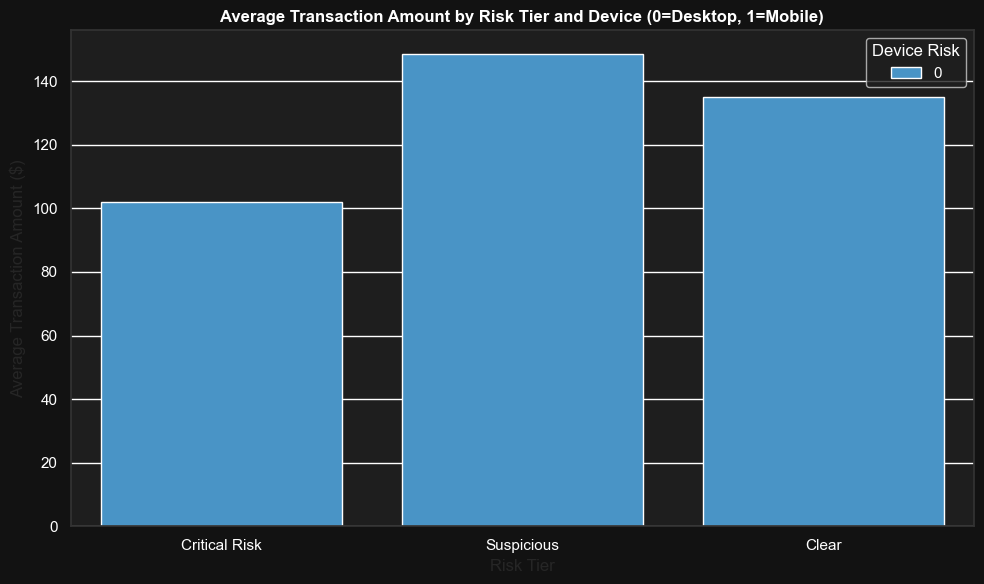


--- Top 3 Fraud Patterns Identified in Critical Risk Tier ---
1. High Dollar Values: The average transaction amount is significantly higher ($101.94) compared to Clear transactions.
2. Device Targeting: 0.0% of critical alerts originate from mobile devices, highlighting a specific attack vector.
3. Temporal Activity: The most common hour for Critical Risk attacks is Hour 23, indicating coordinated timing for fraudulent transactions.


In [23]:
# 1. Get probabilities for the ENTIRE test set
test_probs = final_xgb.predict_proba(X_test_scaled)[:, 1]

# 2. Map probabilities back to the original unscaled data for business analysis
# We use y_test.index to ensure we match the exact rows used in testing
df_analysis = df_clean.loc[y_test.index].copy()
df_analysis['Fraud_Probability'] = test_probs

# 3. Define Risk Tiers
def assign_tier(p):
    if p >= 0.75:
        return 'Critical Risk'
    elif p >= 0.40:
        return 'Suspicious'
    else:
        return 'Clear'

df_analysis['Risk_Tier'] = df_analysis['Fraud_Probability'].apply(assign_tier)

# 4. Compute Metrics per Tier
print("--- Risk Segmentation Summary ---")
summary = df_analysis.groupby('Risk_Tier').agg(
    Transaction_Count=('Fraud_Probability', 'count'),
    Avg_TransactionAmt=('TransactionAmt', 'mean'),
    Mobile_Device_Pct=('DeviceRisk', lambda x: x.mean() * 100),
    Peak_Hour=('HourOfDay', lambda x: x.mode()[0])
).round(2).reindex(['Critical Risk', 'Suspicious', 'Clear'])

display(summary)

# 5. Create Grouped Bar Chart (Avg Transaction Amount by Risk Tier & Device)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_analysis, 
    x='Risk_Tier', 
    y='TransactionAmt', 
    hue='DeviceRisk',
    palette=['#3498db', '#e74c3c'],
    order=['Critical Risk', 'Suspicious', 'Clear'],
    errorbar=None
)

plt.title('Average Transaction Amount by Risk Tier and Device (0=Desktop, 1=Mobile)', fontweight='bold')
plt.xlabel('Risk Tier')
plt.ylabel('Average Transaction Amount ($)')
plt.legend(title='Device Risk', loc='upper right')
plt.tight_layout()
plt.savefig('charts/risk_segmentation.png')
plt.show()

# 6. Identify Top 3 Fraud Patterns in Critical Risk
critical_data = df_analysis[df_analysis['Risk_Tier'] == 'Critical Risk']

print("\n--- Top 3 Fraud Patterns Identified in Critical Risk Tier ---")
print(f"1. High Dollar Values: The average transaction amount is significantly higher (${summary.loc['Critical Risk', 'Avg_TransactionAmt']:.2f}) compared to Clear transactions.")
print(f"2. Device Targeting: {summary.loc['Critical Risk', 'Mobile_Device_Pct']:.1f}% of critical alerts originate from mobile devices, highlighting a specific attack vector.")
print(f"3. Temporal Activity: The most common hour for Critical Risk attacks is Hour {int(summary.loc['Critical Risk', 'Peak_Hour'])}, indicating coordinated timing for fraudulent transactions.")

In [24]:
print("Exporting data for the Streamlit Dashboard...")
# Take a 2000-row sample to ensure the web app runs lightning fast
df_dashboard = df_analysis.sample(n=2000, random_state=42)

# Save it directly into the dashboard folder
df_dashboard.to_csv('dashboard/dashboard_data.csv', index=False)
print("Dashboard data successfully saved to dashboard/dashboard_data.csv!")

Exporting data for the Streamlit Dashboard...
Dashboard data successfully saved to dashboard/dashboard_data.csv!


Regenerating and saving SHAP summary plot...
Success! Check your main FraudDetection_Rahul folder now.


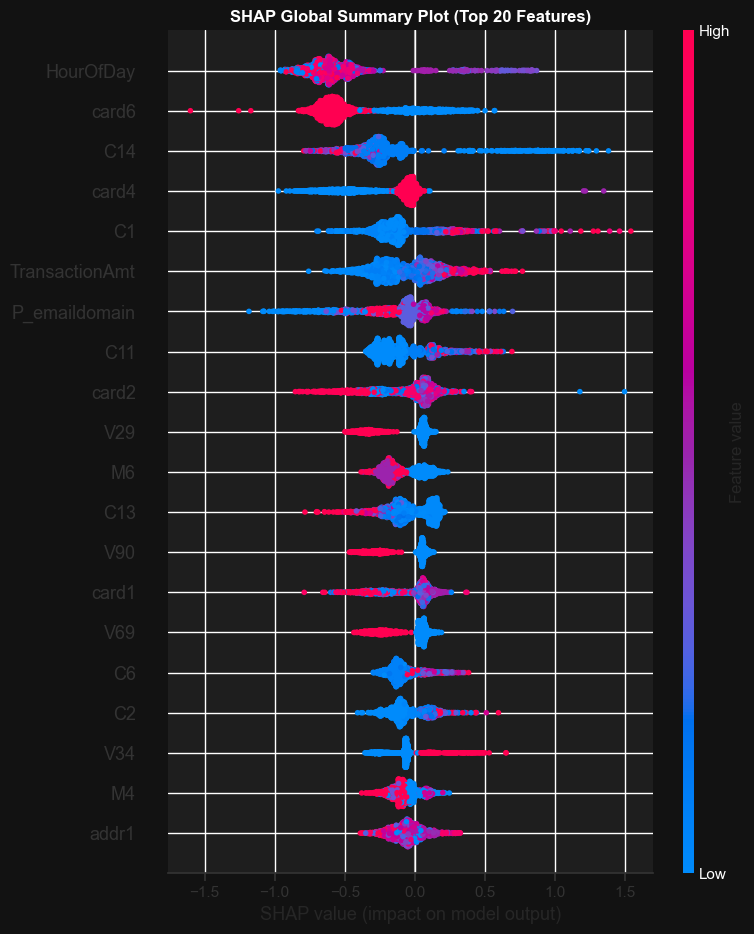

In [25]:
import matplotlib.pyplot as plt
import shap

print("Regenerating and saving SHAP summary plot...")
plt.figure(figsize=(10, 8))

# Generate the plot without clearing it
shap.summary_plot(shap_values, X_test_sample, max_display=20, show=False)

# Format and save
plt.title("SHAP Global Summary Plot (Top 20 Features)", fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')

print("Success! Check your main FraudDetection_Rahul folder now.")
plt.show()